# Forward Process

The forward process gradually destroys an image by adding Gaussian noise over T timesteps.

At each step:
$$q(x_t | x_{t-1}) = \mathcal{N}(x_t;\ \sqrt{1-\beta_t}\, x_{t-1},\ \beta_t \mathbf{I})$$

But we can jump directly to any timestep t in closed form:
$$x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \mathbf{I})$$

where $\alpha_t = 1 - \beta_t$ and $\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s$.

In [1]:
import torch
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms

## Noise Schedule

The schedule defines how quickly we destroy the signal. We use a **linear schedule**: $\beta_t$ increases linearly from $\beta_1$ to $\beta_T$.

Small $\beta$ early on preserves signal; large $\beta$ later destroys it rapidly.

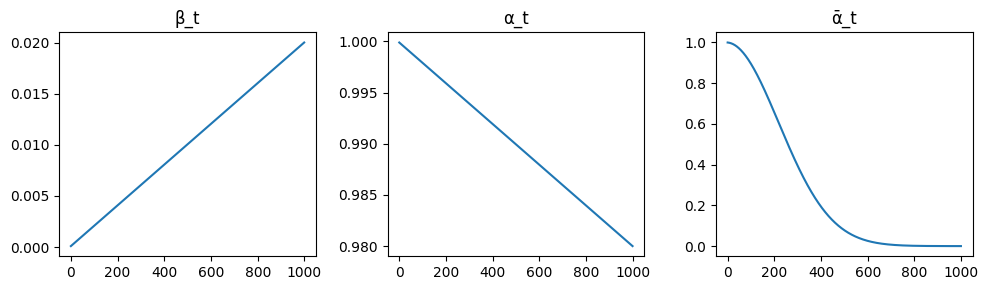

In [2]:
T = 1000
beta_start = 1e-4
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, T)        # β_t
alphas = 1.0 - betas                                    # α_t
alpha_bars = torch.cumprod(alphas, dim=0)               # ᾱ_t

plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1); plt.plot(betas);       plt.title('β_t')
plt.subplot(1, 3, 2); plt.plot(alphas);      plt.title('α_t')
plt.subplot(1, 3, 3); plt.plot(alpha_bars);  plt.title('ᾱ_t')
plt.tight_layout()
plt.show()

## Forward Process

Load one MNIST image and apply the closed-form forward process at several timesteps.

In [3]:
dataset = torchvision.datasets.MNIST(root='../data', train=True, download=True,
                                     transform=transforms.ToTensor())

100.0%
100.0%
100.0%
100.0%


In [11]:
x0, _ = dataset[0]  # shape: (1, 28, 28), values in [0, 1]

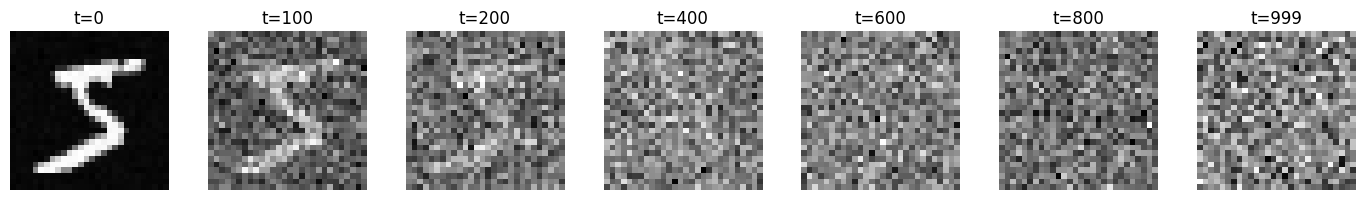

In [12]:
def forward(x0, t):
    ab = alpha_bars[t]
    eps = torch.randn_like(x0)
    xt = ab.sqrt() * x0 + (1 - ab).sqrt() * eps
    return xt, eps

timesteps = [0, 100, 200, 400, 600, 800, 999]

fig, axes = plt.subplots(1, len(timesteps), figsize=(14, 2))
for ax, t in zip(axes, timesteps):
    xt, _ = forward(x0, t)
    ax.imshow(xt.squeeze(), cmap='gray')
    ax.set_title(f't={t}')
    ax.axis('off')
plt.tight_layout()
plt.show()